# TrueCar Price Tier Classification: Logistic Regression, AIC/BIC, and Predictive Models

This notebook treats `price_tier` as a classification target. The goal is to predict whether
a car is below, near, or above market based on listing attributes.


## Hypotheses

**Baseline hypothesis**

- $H_0$: Listing features do not improve classification beyond predicting the majority class.
- $H_A$: Listing features improve classification performance beyond the majority-class baseline.

**Logistic-regression hypothesis**

For likelihood-based inference, we use a binary logistic model for `below_market`
versus `not_below_market`. Each coefficient changes the log-odds of being below
market. We compare nested models using log-likelihood, AIC, and BIC.

For final prediction, we return to the full multiclass target: `below_market`,
`near_market`, and `above_market`.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("../data")
CLEAN_DATA = DATA_DIR / "truecar_clean_combined.csv"
MODEL_DATA = DATA_DIR / "truecar_model_ready.csv"


In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## Import Classification Data


In [3]:
cars = pd.read_csv(MODEL_DATA if MODEL_DATA.exists() else CLEAN_DATA)
cars = cars.dropna(subset=["price_tier", "sales_price", "odometer_miles", "vehicle_age", "make", "model"]).copy()
cars["log_odometer"] = np.log1p(cars["odometer_miles"])

print(cars.shape)
cars["price_tier"].value_counts(normalize=True).to_frame("class_rate")


(8449, 17)


,class_rate
price_tier,
below_market,0.679607
near_market,0.310096
above_market,0.010297


## Baseline Classifier


In [4]:
X_cols = [
    "vehicle_age", "odometer_miles", "dealer_distance_miles", "feature_count", "standard_feature_count",
    "make", "model", "fuel_type", "exterior", "interior", "dealer_state", "source_metro",
]
X_cols = [c for c in X_cols if c in cars.columns]

X = cars[X_cols]
y = cars["price_tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=571, stratify=y
)

majority_class = y_train.mode()[0]
baseline_pred = np.repeat(majority_class, len(y_test))

baseline = {
    "model": "Majority class baseline",
    "accuracy": accuracy_score(y_test, baseline_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, baseline_pred),
    "macro_f1": f1_score(y_test, baseline_pred, average="macro"),
}
baseline


{'model': 'Majority class baseline',
 'accuracy': 0.6796024609559868,
 'balanced_accuracy': 0.3333333333333333,
 'macro_f1': 0.2697473466704236}

## Logistic Regression with AIC/BIC


In [5]:
# For an interpretable statsmodels model, use a binary target and lump high-cardinality makes.
top_makes = cars["make"].value_counts().head(10).index
sm_data = cars.assign(make_lumped=np.where(cars["make"].isin(top_makes), cars["make"], "Other"))
sm_data["below_market"] = (sm_data["price_tier"] == "below_market").astype(int)

base_formula = "below_market ~ log_odometer + vehicle_age"
full_formula = "below_market ~ log_odometer + vehicle_age + feature_count + C(source_metro) + C(make_lumped)"

logit_base = smf.logit(base_formula, data=sm_data).fit(method="lbfgs", maxiter=500, disp=False)
logit_full = smf.logit(full_formula, data=sm_data).fit(method="lbfgs", maxiter=500, disp=False)

logit_compare = pd.DataFrame({
    "model": ["base", "full"],
    "log_likelihood": [logit_base.llf, logit_full.llf],
    "AIC": [logit_base.aic, logit_full.aic],
    "BIC": [logit_base.bic, logit_full.bic],
})
logit_compare


C:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


,model,log_likelihood,AIC,BIC
0,base,-4927.696389,9861.392779,9882.518189
1,full,-4533.853320,9105.706641,9239.500905


Lower AIC/BIC indicates a better tradeoff between fit and complexity. If the full model has
much lower AIC/BIC than the base model, the additional vehicle and market variables are
carrying useful classification information.


## Predictive Classification Pipelines


In [6]:
numeric_features = [c for c in ["vehicle_age", "odometer_miles", "dealer_distance_miles", "feature_count", "standard_feature_count"] if c in X.columns]
categorical_features = [c for c in ["make", "model", "fuel_type", "exterior", "interior", "dealer_state", "source_metro"] if c in X.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]), categorical_features),
    ],
    remainder="drop",
    sparse_threshold=0.0,
)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced", random_state=571, n_jobs=1),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(max_iter=250, learning_rate=0.06, random_state=571),
}

rows = [baseline]
fitted_classifiers = {}
for name, estimator in classifiers.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    fitted_classifiers[name] = pipe
    pred = pipe.predict(X_test)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
    })

class_results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
class_results


  File "C:\Program Files\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,model,accuracy,balanced_accuracy,macro_f1
2,Random Forest,0.729295,0.493882,0.476848
3,Histogram Gradient Boosting,0.735920,0.457552,0.458803
1,Logistic Regression,0.624231,0.433743,0.433389
0,Majority class baseline,0.679602,0.333333,0.269747


## Cross-Validation


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=571)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
}

cv_rows = []
for name, estimator in classifiers.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "model": name,
        "CV_accuracy": scores["test_accuracy"].mean(),
        "CV_balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "CV_macro_f1": scores["test_macro_f1"].mean(),
    })

pd.DataFrame(cv_rows).sort_values("CV_macro_f1", ascending=False)


,model,CV_accuracy,CV_balanced_accuracy,CV_macro_f1
1,Random Forest,0.714878,0.504672,0.485070
2,Histogram Gradient Boosting,0.746480,0.466990,0.468053
0,Logistic Regression,0.606699,0.433160,0.427469


## Confusion Matrix and Class-Level Metrics


Random Forest
              precision    recall  f1-score   support

above_market       0.00      0.00      0.00        22
below_market       0.86      0.73      0.79      1436
 near_market       0.56      0.75      0.64       655

    accuracy                           0.73      2113
   macro avg       0.47      0.49      0.48      2113
weighted avg       0.76      0.73      0.74      2113



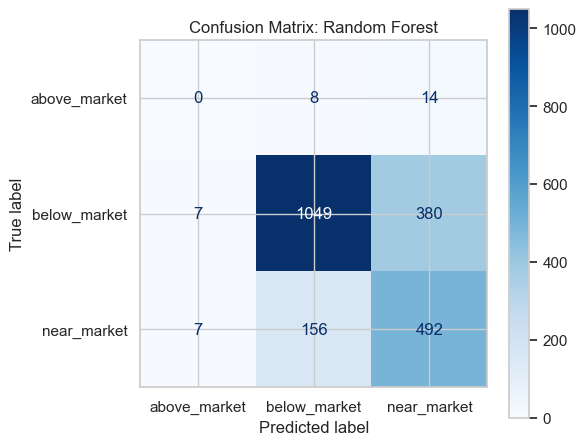

In [8]:
best_name = class_results.iloc[0]["model"]
if best_name == "Majority class baseline":
    best_name = class_results.iloc[1]["model"]

best_classifier = fitted_classifiers[best_name]
best_pred = best_classifier.predict(X_test)

print(best_name)
print(classification_report(y_test, best_pred))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix: {best_name}")
plt.tight_layout()


## Probability Scores for Decision Support


In [9]:
if hasattr(best_classifier.named_steps["model"], "predict_proba"):
    proba = best_classifier.predict_proba(X_test)
    proba_df = pd.DataFrame(proba, columns=best_classifier.named_steps["model"].classes_, index=X_test.index)
    examples = cars.loc[X_test.index, ["make", "model", "sales_price", "price_tier"]].join(proba_df)
    examples.head(10)


## Conclusion

Accuracy alone is not enough for this task because `price_tier` is imbalanced. Balanced
accuracy, macro F1, and confusion matrices show whether the model is learning minority
classes or simply predicting the dominant class. The statistical logistic model supports
likelihood-based comparison, while the sklearn pipelines provide a stronger final
predictive workflow.
